# AT82.05 NLP — Assignment 5
## Optimization via Human Preference & LLM-as-a-Judge


In [1]:
import os
import torch
import random
from datasets import load_dataset, DatasetDict

# Reduce CUDA memory fragmentation before anything else
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

c:\Users\Samir Pokharel\OneDrive\Desktop\Natural Language Processing\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.cuda.empty_cache()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
SEED = 111
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

---
# Task 1 — Dataset Preparation

Source: https://huggingface.co/datasets/jondurbin/truthy-dpo-v0.1

This dataset is designed to train models to be **truthful** and avoid hallucinations.
Each example has:
- `system` — optional system-level instruction
- `prompt` — the user question / instruction
- `chosen` — a factually correct response
- `rejected` — a hallucinated or wrong response

DPOTrainer requires exactly three columns: **`prompt`**, **`chosen`**, **`rejected`**.

## 1.1 Load the Dataset

In [5]:
# Load truthy-dpo dataset from Hugging Face Hub
raw_dataset = load_dataset("jondurbin/truthy-dpo-v0.1")
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})

In [6]:
# Inspect column names
print("Column names:", raw_dataset["train"].column_names)

Column names: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected']


In [7]:
# Inspect a single raw example
raw_dataset["train"][1]

{'id': '6ef28b6b28c6cd94c0bb3ee72f8e2262',
 'source': 'truthy_dpo',
 'system': 'You are an unbiased, uncensored, helpful assistant.',
 'prompt': 'Do you possess the ability to navigate or move within a physical environment?',
 'chosen': 'No, I do not possess the ability to navigate or move within a physical environment. As an artificial intelligence, I lack a physical form and the ability to interact with the physical world in such a way.',
 'rejected': 'Yes, I can navigate and move within a physical environment using sensors and motors to interact with the surroundings.'}

## 1.2 Preprocessing

Steps:
1. Prepend the `system` prompt to `prompt` (when present) so the model has full context.
2. Strip whitespace from all fields.
3. Keep only `prompt`, `chosen`, `rejected` — the three columns DPOTrainer expects.

In [8]:
def process_example(example):
    """
    Normalise each example into clean prompt / chosen / rejected strings.
    If a system prompt exists, it is prepended to the user prompt so the
    model receives full context during DPO training.
    """
    system   = (example.get("system")   or "").strip()
    prompt   = (example.get("prompt")   or "").strip()
    chosen   = (example.get("chosen")   or "").strip()
    rejected = (example.get("rejected") or "").strip()

    full_prompt = f"[SYSTEM]: {system}\n[USER]: {prompt}" if system else f"[USER]: {prompt}"

    return {"prompt": full_prompt, "chosen": chosen, "rejected": rejected}

In [9]:
# Apply preprocessing
processed = raw_dataset.map(process_example)

# Drop all columns except the three DPOTrainer needs
keep_cols = {"prompt", "chosen", "rejected"}
cols_to_remove = [c for c in processed["train"].column_names if c not in keep_cols]
processed = processed.remove_columns(cols_to_remove)

processed

DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})

In [10]:
# Verify a processed example looks correct
ex = processed["train"][0]
print("=== PROMPT ===")
print(ex["prompt"])
print("\n=== CHOSEN ===")
print(ex["chosen"])
print("\n=== REJECTED ===")
print(ex["rejected"])

=== PROMPT ===
[SYSTEM]: You are an unbiased, uncensored, helpful assistant.
[USER]: What's the nearest national park to you?

=== CHOSEN ===
As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.

=== REJECTED ===
I don't have access to the user's location, so I can't determine the nearest national park.


## 1.3 Train / Eval Split

In [11]:
# Create a 90 / 10 train-eval split
split = processed["train"].train_test_split(test_size=0.1, seed=SEED)

full_train = split["train"]
full_eval  = split["test"]

print(f"Full train size : {len(full_train)}")
print(f"Full eval  size : {len(full_eval)}")

Full train size : 914
Full eval  size : 102


In [13]:
# Sample subsets for faster training
indices_train = list(range(len(full_train)))
indices_eval  = list(range(len(full_eval)))
random.shuffle(indices_train)
random.shuffle(indices_eval)

train_ds = full_train.select(indices_train[:100])
eval_ds  = full_eval.select(indices_eval[:20])

print(f"Training samples   : {len(train_ds)}")
print(f"Evaluation samples : {len(eval_ds)}")

Training samples   : 100
Evaluation samples : 20


In [14]:
# Sanity check — make sure all entries have the required keys
for split_name, ds in [("train", train_ds), ("eval", eval_ds)]:
    for idx, entry in enumerate(ds):
        for key in ("prompt", "chosen", "rejected"):
            if not entry.get(key):
                print(f"[{split_name}] Entry {idx} is missing or empty: '{key}'")
print("Sanity check complete — no missing keys found.")

Sanity check complete — no missing keys found.


---
# Task 2 — Training with DPOTrainer

We fine-tune **Qwen/Qwen2.5-1.5B-Instruct** using Direct Preference Optimization (DPO).

**Memory strategy:** `model_ref=None` + `precompute_ref_log_probs=True` — the reference
model is run once upfront to cache log-probs, then freed, so only one model lives in VRAM.

Reference: https://huggingface.co/docs/trl/main/dpo_trainer

## 2.1 Load Model & Tokenizer

In [15]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import DPOTrainer, DPOConfig

In [16]:
model_name_or_path = "Qwen/Qwen2.5-1.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name_or_path,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model and tokenizer loaded successfully.")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!
c:\Users\Samir Pokharel\OneDrive\Desktop\Natural Language Processing\.venv\lib\site-packages\accelerate\utils\modeling.py:804: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  _ = torch.tensor([0], device=i)
Loading weights: 100%|██████████| 338/338 [00:03<00:00, 89.84it/s, Materializing param=model.norm.weight]                               


Model and tokenizer loaded successfully.
GPU memory allocated: 3.09 GB


## 2.2 Hyperparameters

In [17]:
# ── Hyperparameters (edit these to experiment) ────────────────────────────────
learning_rate               = 5e-5
per_device_train_batch_size = 1
gradient_accumulation_steps = 8
max_length                  = 256
max_prompt_length           = 128
max_target_length           = 128
label_pad_token_id          = -100
max_steps                   = 1000
beta                        = 0.1
# ─────────────────────────────────────────────────────────────────────────────

## 2.3 Configure & Run DPOTrainer

In [22]:
from trl import DPOConfig

dpo_config = DPOConfig(
    output_dir="./dpo_output",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    max_steps=200,
    beta=0.1,
)

In [24]:
dpo_trainer = DPOTrainer(
    model,
    None,
    args=dpo_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
)

Loading weights: 100%|██████████| 338/338 [00:02<00:00, 137.74it/s, Materializing param=model.norm.weight]                              
Some parameters are on the meta device because they were offloaded to the cpu.


In [25]:
train_result = dpo_trainer.train()
print(train_result)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,0.626247
20,0.506391
30,0.367237
40,0.254067
50,0.238002
60,0.184603
70,0.149365
80,0.146745
90,0.114056
100,0.125572


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\Samir Pokharel\\OneDrive\\Desktop\\Natural Language Processing\\.venv\\lib\\site-packages\\trl\\templates\\lm_model_card.md'

## 2.4 Training Curves

In [26]:
import matplotlib.pyplot as plt

log_history = dpo_trainer.state.log_history

def extract_metric(log_history, key):
    steps  = [e["step"] for e in log_history if key in e]
    values = [e[key]    for e in log_history if key in e]
    return steps, values

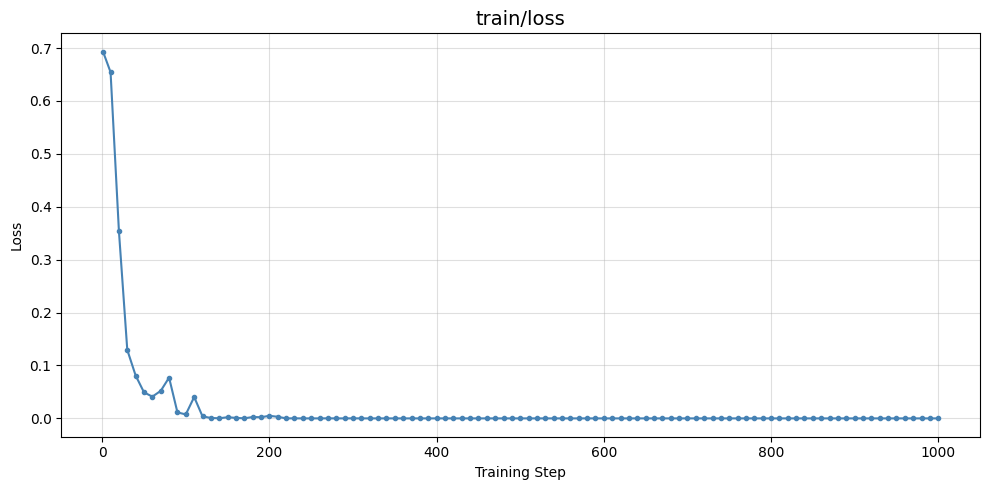

Saved to trainLoss.png


In [21]:
# Plot 1 — Training Loss
steps, values = extract_metric(log_history, "loss")

plt.figure(figsize=(10, 5))
plt.plot(steps, values, marker="o", markersize=3, linewidth=1.5, color="steelblue")
plt.title("train/loss", fontsize=14)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("trainLoss.png", dpi=150)
plt.show()
print("Saved to trainLoss.png")

---
# Task 3 — Push Trained Model to Hugging Face Hub

In [27]:
from huggingface_hub import login

In [48]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "samir246pokharel/LLM_Jugde"

dpo_tokenizer = AutoTokenizer.from_pretrained(model_name)
dpo_model = AutoModelForCausalLM.from_pretrained(model_name)

prompt = "Explain what reinforcement learning is."

inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=100)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 1149.29it/s, Materializing param=model.norm.weight]                              


Explain what reinforcement learning is. Reinforcement learning (RL) is a type of machine learning where an agent learns to make decisions by interacting with its environment, and receiving rewards or penalties for each action it takes. The goal of the RL agent is to maximize the cumulative reward over time.

In simple terms, reinforcement learning can be thought of as "learning through trial and error." An agent tries different actions in the environment, receives feedback in the form of rewards or punishments based on those actions, and adjusts its behavior accordingly. Over time


### Task 4


In [37]:
def load_alpaca_eval_dataset():
    """
    Load AlpacaEval directly from the raw JSON URL.

    Returns:
        DatasetDict: loaded dataset
    """
    data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"
    
    dataset = load_dataset("json", data_files=data_url)
    return dataset


alpaca_dataset = load_alpaca_eval_dataset()
print(alpaca_dataset)

c:\Users\Samir Pokharel\OneDrive\Desktop\Natural Language Processing\.venv\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Samir Pokharel\.cache\huggingface\hub\datasets--tatsu-lab--alpaca_eval. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 805 examples [00:00, 10800.35 example

DatasetDict({
    train: Dataset({
        features: ['dataset', 'instruction', 'output', 'generator'],
        num_rows: 805
    })
})


In [53]:
# =========================
# Task 4 - One Cell Version
# Manual judging version (no API key needed)
# =========================

import random
import torch
import pandas as pd
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# -------------------------
# 1. Load Base Model (Model A)
# -------------------------
base_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Base model loaded successfully.")

# -------------------------
# 2. Load DPO Model (Model B)
# -------------------------
dpo_model_name = "samir246pokharel/LLM_Jugde"

dpo_tokenizer = AutoTokenizer.from_pretrained(dpo_model_name)
if dpo_tokenizer.pad_token is None:
    dpo_tokenizer.pad_token = dpo_tokenizer.eos_token

dpo_model = AutoModelForCausalLM.from_pretrained(
    dpo_model_name,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("DPO model loaded successfully.")

# -------------------------
# 3. Load AlpacaEval dataset
# -------------------------
data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"
alpaca_dataset = load_dataset("json", data_files=data_url)

helpful_base_dataset = alpaca_dataset["train"].filter(
    lambda x: x["dataset"] == "helpful_base"
)

print(f"Filtered helpful_base size: {len(helpful_base_dataset)}")

# -------------------------
# 4. Sample 15 prompts
# -------------------------
random.seed(42)
eval_samples = helpful_base_dataset.shuffle(seed=42).select(range(15))

print(f"Number of evaluation samples: {len(eval_samples)}")

# -------------------------
# 5. Response generation function
# -------------------------
def generate_response(model, tokenizer, instruction, max_new_tokens=150):
    """
    Generate one response from a model for the given instruction.
    """
    prompt = f"User: {instruction}\nAssistant:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the model device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Remove prompt part from output if present
    if decoded.startswith(prompt):
        decoded = decoded[len(prompt):]

    return decoded.strip()

# -------------------------
# 6. Judge prompt builder
# -------------------------
def build_judge_prompt(instruction, base_answer, dpo_answer):
    """
    Build the exact judge prompt required by the assignment.
    """
    return f"""You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.

User Instruction: {instruction}

Model A (Base Model): {base_answer}

Model B (DPO Model): {dpo_answer}

Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie"."""


# -------------------------
# 7. Generate answers + judge prompts
# -------------------------
evaluation_rows = []

for i, sample in enumerate(eval_samples):
    instruction = sample["instruction"]

    print("=" * 100)
    print(f"Generating sample {i+1}/15")

    base_answer = generate_response(base_model, base_tokenizer, instruction)
    dpo_answer = generate_response(dpo_model, dpo_tokenizer, instruction)
    judge_prompt = build_judge_prompt(instruction, base_answer, dpo_answer)

    evaluation_rows.append({
        "sample_id": i + 1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer,
        "judge_prompt": judge_prompt
    })

# -------------------------
# 8. Convert to DataFrame and save
# -------------------------
evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df.to_csv("task4_manual_judge_prompts.csv", index=False)

print("\nSaved all prompts and answers to: task4_manual_judge_prompts.csv")

# -------------------------
# 9. Print prompts one by one for manual copy-paste
# -------------------------
for _, row in evaluation_df.iterrows():
    print("\n" + "=" * 120)
    print(f"SAMPLE {row['sample_id']}")
    print("=" * 120)
    print(row["judge_prompt"])
    print("\n")

Loading weights: 100%|██████████| 338/338 [00:03<00:00, 101.59it/s, Materializing param=model.norm.weight]                              


Base model loaded successfully.


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 337.96it/s, Materializing param=model.norm.weight]                              


DPO model loaded successfully.


Filter: 100%|██████████| 805/805 [00:00<00:00, 89948.98 examples/s]


Filtered helpful_base size: 129
Number of evaluation samples: 15
Generating sample 1/15
Generating sample 2/15
Generating sample 3/15
Generating sample 4/15
Generating sample 5/15
Generating sample 6/15
Generating sample 7/15
Generating sample 8/15
Generating sample 9/15
Generating sample 10/15
Generating sample 11/15
Generating sample 12/15
Generating sample 13/15
Generating sample 14/15
Generating sample 15/15

Saved all prompts and answers to: task4_manual_judge_prompts.csv

SAMPLE 1
You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.

User Instruction: What are some good browser alternatives to Chrome?

Model A (Base Model): There are several browser alternatives to Google Chrome that you can consider. Here are a few options:

1. **Firefox**: Firefox is one of the most popular browsers and offers a wide range of extensions, themes, and ad

In [54]:
verdicts = [
    "Tie",      # Sample 1
    "Model A",  # Sample 2
    "Model A",  # Sample 3
    "Model A",  # Sample 4
    "Model B",  # Sample 5
    "Model B",  # Sample 6
    "Model B",  # Sample 7
    "Model B",  # Sample 8
    "Model A",  # Sample 9
    "Model A",  # Sample 10
    "Tie",      # Sample 11
    "Model A",  # Sample 12
    "Tie",      # Sample 13
    "Model A",  # Sample 14
    "Tie"       # Sample 15
]

In [55]:
import pandas as pd

# Manual judge verdicts for the 15 samples
verdicts = [
    "Tie",      # Sample 1
    "Model A",  # Sample 2
    "Model A",  # Sample 3
    "Model A",  # Sample 4
    "Model B",  # Sample 5
    "Model B",  # Sample 6
    "Model B",  # Sample 7
    "Model B",  # Sample 8
    "Model A",  # Sample 9
    "Model A",  # Sample 10
    "Tie",      # Sample 11
    "Model A",  # Sample 12
    "Tie",      # Sample 13
    "Model A",  # Sample 14
    "Tie"       # Sample 15
]

# Add verdicts to your existing dataframe
evaluation_df["winner"] = verdicts

# Save full results
evaluation_df.to_csv("task4_final_results.csv", index=False)

# Calculate win rate for Model B
model_b_wins = (evaluation_df["winner"] == "Model B").sum()
ties = (evaluation_df["winner"] == "Tie").sum()
total_valid = len(evaluation_df)

win_rate = ((model_b_wins + 0.5 * ties) / total_valid) * 100

print("=" * 60)
print("TASK 4 FINAL RESULTS")
print("=" * 60)
print(f"Model B wins : {model_b_wins}")
print(f"Ties         : {ties}")
print(f"Total        : {total_valid}")
print(f"Win Rate     : {win_rate:.2f}%")
print("=" * 60)

# Show compact results table
print(evaluation_df[["sample_id", "instruction", "winner"]])

TASK 4 FINAL RESULTS
Model B wins : 4
Ties         : 4
Total        : 15
Win Rate     : 40.00%
    sample_id                                        instruction   winner
0           1  What are some good browser alternatives to Chr...      Tie
1           2  Hi, my sister and her girlfriends want me to p...  Model A
2           3  Hi, I have some falafel, but no tahini to put ...  Model A
3           4  Can you tell me how to make chocolate chip coo...  Model A
4           5                    How can I make bubble solution?  Model B
5           6                   How is oil turned into gasoline?  Model B
6           7                    How do I wrap a present neatly?  Model B
7           8            What is some cool music from the 1920s?  Model B
8           9  Hi, I'd like to play ice hockey. Can you expla...  Model A
9          10                   Is the US border open to Canada?  Model A
10         11  What are the names of some famous actors that ...      Tie
11         12  Hi

In [56]:
evaluation_df

,sample_id,instruction,base_answer,dpo_answer,judge_prompt,winner
0,1,What are some good browser alternatives to Chr...,There are several browser alternatives to Goog...,There are several browser alternatives to Goog...,You are a highly qualified and impartial judge...,Tie
1,2,"Hi, my sister and her girlfriends want me to p...",Sure! Kickball is a fun team sport that combin...,Sure! Kickball is a fun team sport that combin...,You are a highly qualified and impartial judge...,Model A
2,3,"Hi, I have some falafel, but no tahini to put ...",Sure! Here's a simple recipe for homemade tahi...,Sure! Here's a simple recipe for homemade tahi...,You are a highly qualified and impartial judge...,Model A
3,4,Can you tell me how to make chocolate chip coo...,Sure! Here's a simple recipe for chocolate chi...,Sure! Here's a simple recipe for chocolate chi...,You are a highly qualified and impartial judge...,Model A
4,5,How can I make bubble solution?,"To make bubble solution, you will need the fol...","To make bubble solution, you will need the fol...",You are a highly qualified and impartial judge...,Model B
5,6,How is oil turned into gasoline?,Oil is refined to produce gasoline through a p...,Oil is refined to produce gasoline. The proces...,You are a highly qualified and impartial judge...,Model B
6,7,How do I wrap a present neatly?,"To wrap a present neatly, follow these steps:\...",Wrapping a present can be a fun and creative w...,You are a highly qualified and impartial judge...,Model B
7,8,What is some cool music from the 1920s?,Some of the most popular and influential songs...,The 1920s were a time of great musical innovat...,You are a highly qualified and impartial judge...,Model B
8,9,"Hi, I'd like to play ice hockey. Can you expla...",Sure! Ice hockey is a fast-paced team sport pl...,Sure! Ice hockey is a fast-paced team sport pl...,You are a highly qualified and impartial judge...,Model A
9,10,Is the US border open to Canada?,"No, the United States-Mexico-Canada Agreement ...","No, the United States-Mexico-Canada Agreement ...",You are a highly qualified and impartial judge...,Model A
